# **PHÂN TÍCH DỮ LIỆU: College Majors 2026 – Earnings, Debt, Jobs, AI**
Dành cho Google Colab | Tác giả: Oriana

**HƯỚNG DẪN SỬ DỤNG TRÊN GOOGLE COLAB:**
1. Upload file college_majors_2026.csv lên Colab (hoặc Google Drive)
2. Chạy từng cell theo thứ tự từ trên xuống dưới
3. File cleaned_college_majors.csv sẽ được tạo tự động để download


## **1. CÀI ĐẶT & IMPORT THƯ VIỆN**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Cài đặt style chung cho biểu đồ
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("muted")

print("Thư viện đã sẵn sàng.")

Thư viện đã sẵn sàng.


## **2. ĐỌC DỮ LIỆU**

In [ ]:
FILE_PATH = "/college_majors_2026.csv"

df_raw = pd.read_csv(FILE_PATH, low_memory=False)

print(f"📂 Đã đọc file: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print("\n📋 Danh sách cột:")
print(df_raw.columns.tolist())
print("\n🔍 5 dòng đầu:")
df_raw.head()

📂 Đã đọc file: 227,980 dòng × 72 cột

📋 Danh sách cột:
['program_id', 'unitid', 'opeid6', 'institution_name', 'institution_control', 'is_main_campus', 'institution_city', 'institution_state', 'institution_region', 'institution_latitude', 'institution_longitude', 'institution_is_hbcu', 'institution_admission_rate', 'institution_avg_sat', 'institution_undergrad_enrollment', 'institution_tuition_in_state_usd', 'institution_tuition_out_state_usd', 'cip_code_4digit', 'cip_title', 'cip_family_code', 'cip_family_title', 'credential_level', 'credential_name', 'distance_education', 'awards_year1', 'awards_year2', 'outcomes_shared_across_campuses', 'median_earnings_4yr_usd', 'earnings_cohort_size_4yr', 'national_median_earnings_4yr_usd', 'national_p25_earnings_4yr_usd', 'national_p75_earnings_4yr_usd', 'earnings_vs_national_pct', 'median_earnings_1yr_usd', 'earnings_cohort_size_1yr', 'median_earnings_5yr_usd', 'earnings_cohort_size_5yr', 'not_working_count_5yr', 'count_above_hs_threshold_5yr', '

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,1.0,0.053,0.368,1.0,31.95,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.000,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.167,0.0,18.11,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed
3,493868-12.04-1,493868.0,42833,A Better U Beauty Barber Academy,"Private, for-profit",1,Albuquerque,NM,Southwest,35.110630,...,0.0,0.000,0.000,0.0,5.12,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
4,177834-13.06-5,177834.0,2477,A T Still University of Health Sciences,"Private, nonprofit",1,Kirksville,MO,Plains,40.193648,...,2.0,0.333,0.333,2.0,35.00,Angoss KnowledgeSEEKER; SAS Enterprise Miner; ...,privacy_suppressed,not_available,not_available,not_available


## **3. LÀM SẠCH DỮ LIỆU**

In [ ]:
# ── 3.1  Tạo bản sao để không làm hỏng dữ liệu gốc ─────────────────────────
df = df_raw.copy()

# ── 3.2  Kiểm tra missing values ────────────────────────────────────────────
# Tính % missing cho từng cột, in ra các cột có >0% missing
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("📊 % Missing values (chỉ in cột có missing):")
print(missing_pct[missing_pct > 0].to_string())

# ── 3.3  Xác định nhóm cột số & văn bản ────────────────────────────────────
# Các cột số quan trọng liên quan đến thu nhập, nợ, AI
NUMERIC_COLS = [
    "median_earnings_4yr_usd",
    "median_earnings_1yr_usd",
    "median_earnings_5yr_usd",
    "median_debt_usd",
    "median_monthly_payment_usd",
    "debt_to_earnings_1yr",
    "debt_to_earnings_4yr",
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation",
    "occupation_median_wage_2024_usd",
    "occupation_growth_pct_2024_34",
    "earnings_vs_national_pct",
    "pct_working_5yr",
    "pct_above_hs_threshold_5yr",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    "institution_undergrad_enrollment",
    "institution_admission_rate",
]

# Đảm bảo các cột số đều là kiểu float
# pd.to_numeric(..., errors='coerce') chuyển giá trị không hợp lệ thành NaN
# thay vì raise lỗi
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\n✅ Đã ép kiểu float cho các cột số.")

# ── 3.4  Xử lý cột văn bản ──────────────────────────────────────────────────
TEXT_COLS = [
    "institution_name",
    "institution_control",
    "institution_state",
    "institution_region",
    "cip_title",
    "cip_family_title",
    "credential_name",
    "distance_education",
    "largest_linked_occupation",
    "earnings_trajectory_category",
    "ai_tool_examples",
]

for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        # Chuẩn hóa các biến thể của "không có dữ liệu" về NaN
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan, "N/A": np.nan})

print("✅ Đã chuẩn hóa các cột văn bản.")

# ── 3.5  Xử lý trùng lặp theo OPEID6 ───────────────────────────────────────
# THEO MÔ TẢ DATASET: Một số chương trình được chia sẻ kết quả đầu ra
# (outcomes) giữa nhiều cơ sở (branch campuses) có cùng OPEID6.
# Cột outcomes_shared_across_campuses == 1 đánh dấu các dòng này.
# Ta GIỮ lại tất cả dòng (vì mỗi dòng là một chương trình tại một cơ sở cụ thể),
# nhưng sẽ loại bỏ các dòng HOÀN TOÀN trùng nhau (nếu có).

n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"\n🗑️  Loại bỏ dòng trùng hoàn toàn: {n_before - n_after} dòng bị xóa")
print(f"   Còn lại: {n_after:,} dòng")

# Ghi chú về outcomes_shared_across_campuses
shared = df["outcomes_shared_across_campuses"].sum()
print(f"\nℹ️  Dòng có outcomes_shared_across_campuses=1: {int(shared):,}")
print("   (Đây là branch campuses dùng chung dữ liệu kết quả – KHÔNG xóa)")

# ── 3.6  Thống kê tổng quan sau làm sạch ────────────────────────────────────
print("\n📈 Thống kê mô tả các cột số chính:")
summary_cols = [
    "median_earnings_4yr_usd", "median_debt_usd",
    "debt_to_earnings_4yr", "ai_software_occupation_share",
]
print(df[summary_cols].describe().round(2).to_string())

📊 % Missing values (chỉ in cột có missing):
pct_working_in_state_5yr                82.894552
count_working_in_state_5yr              82.894552
earnings_trajectory_category            82.840161
earnings_growth_pct_1yr_to_5yr          82.840161
payment_to_income_pct_1yr               81.003597
debt_to_earnings_1yr                    81.003597
debt_to_earnings_4yr                    80.974208
count_above_hs_threshold_5yr            80.771998
pct_above_hs_threshold_5yr              80.771998
median_debt_usd                         79.527590
median_monthly_payment_usd              79.527590
median_earnings_5yr_usd                 77.843670
pct_working_5yr                         77.843670
earnings_cohort_size_5yr                77.843670
median_earnings_1yr_usd                 77.091850
earnings_cohort_size_1yr                77.091850
debt_borrower_count                     74.514870
earnings_vs_national_pct                74.511799
earnings_cohort_size_4yr                74.510045
median

## **4. PHÂN TÍCH KHÁM PHÁ (EDA)**

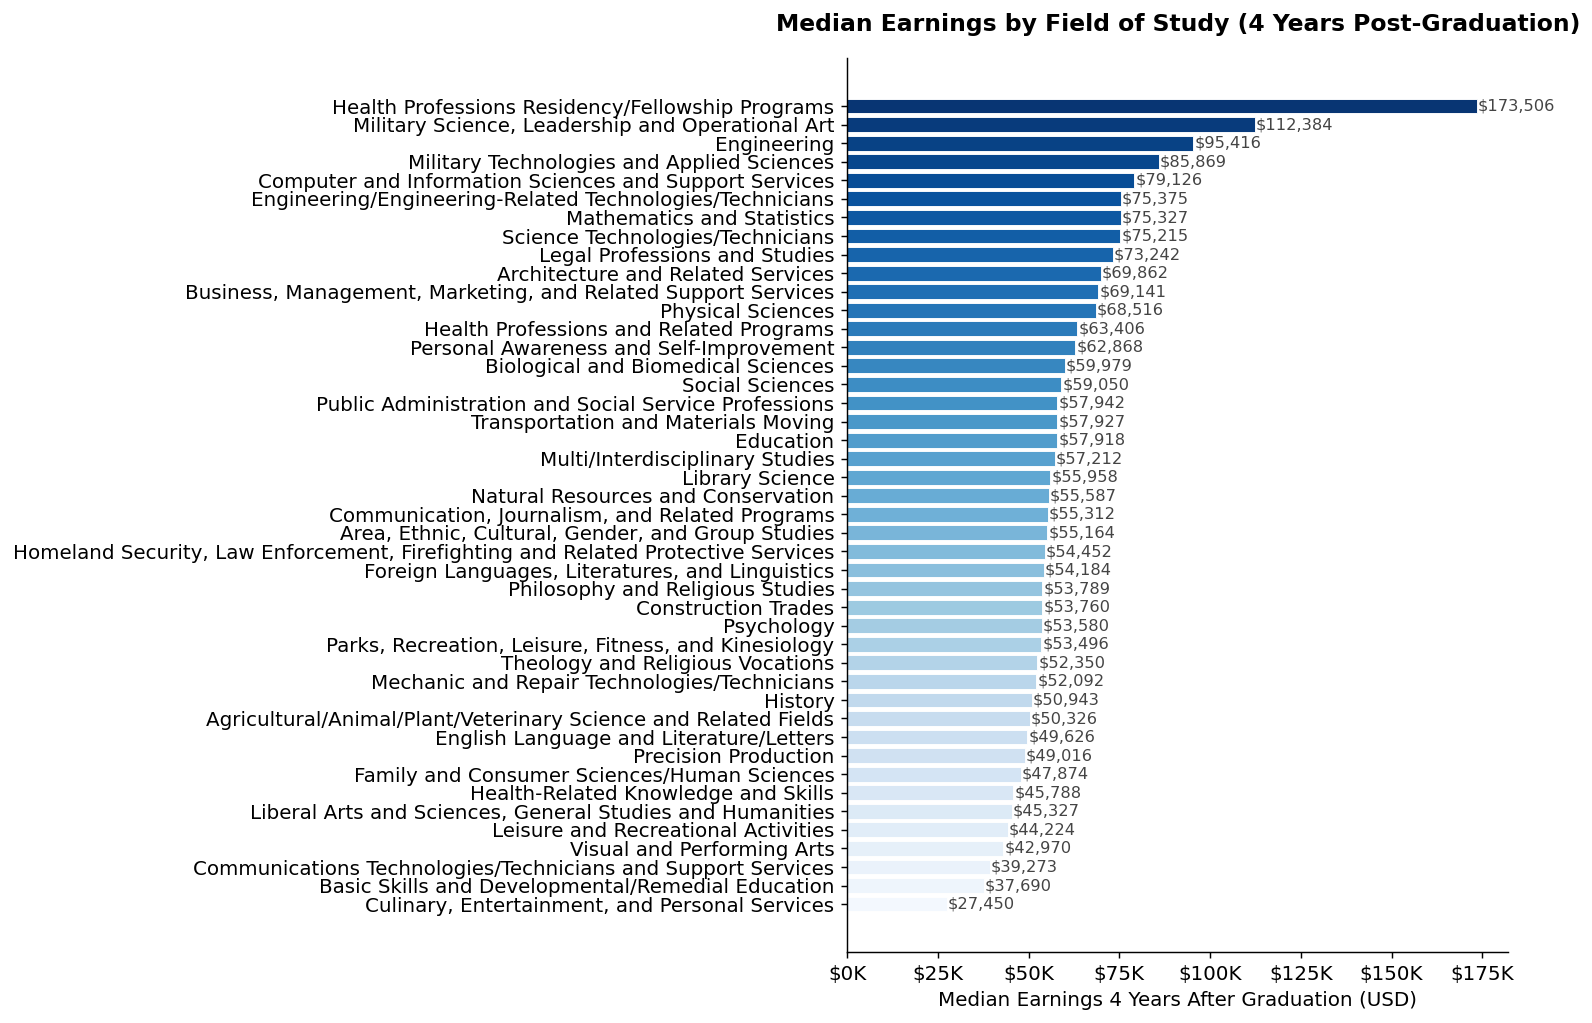

💾 Đã lưu: plot1_earnings_by_field.png


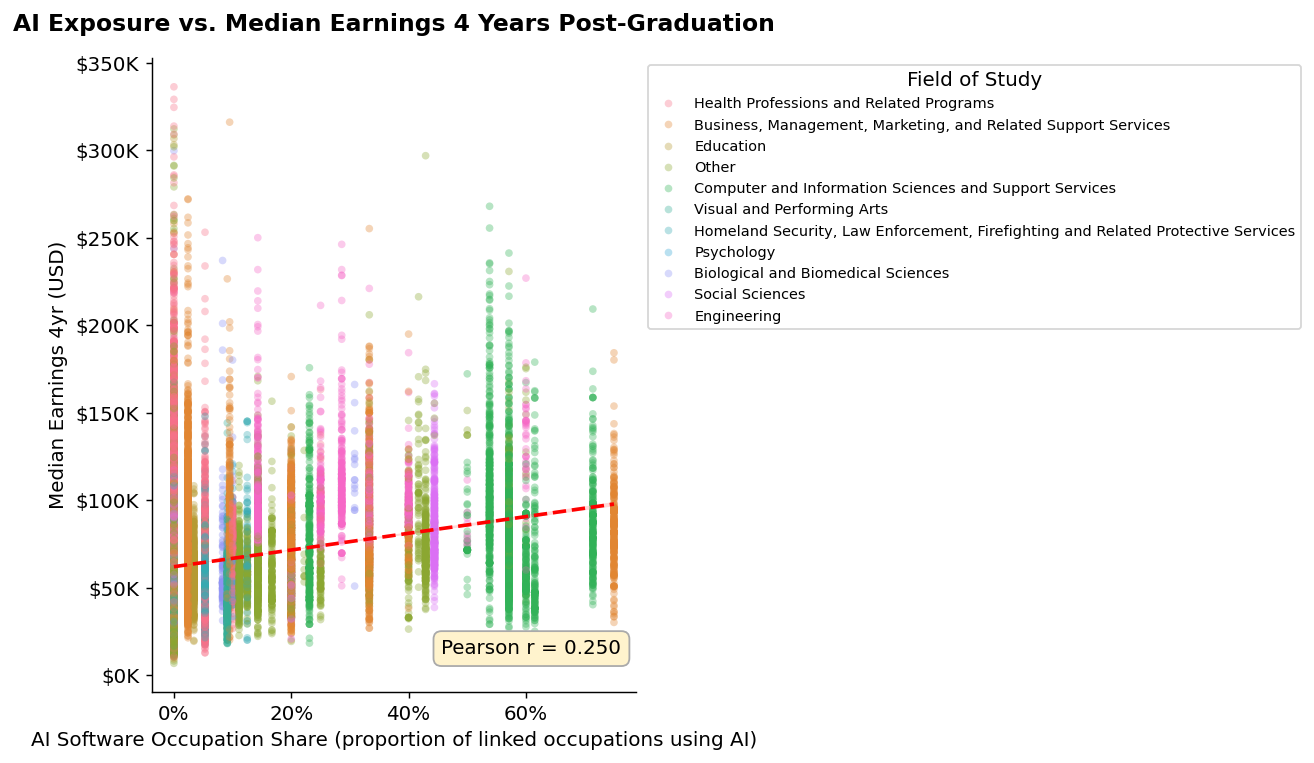

💾 Đã lưu: plot2_ai_vs_earnings.png
📌 Pearson r = 0.250 — tương quan thuận giữa AI exposure và thu nhập


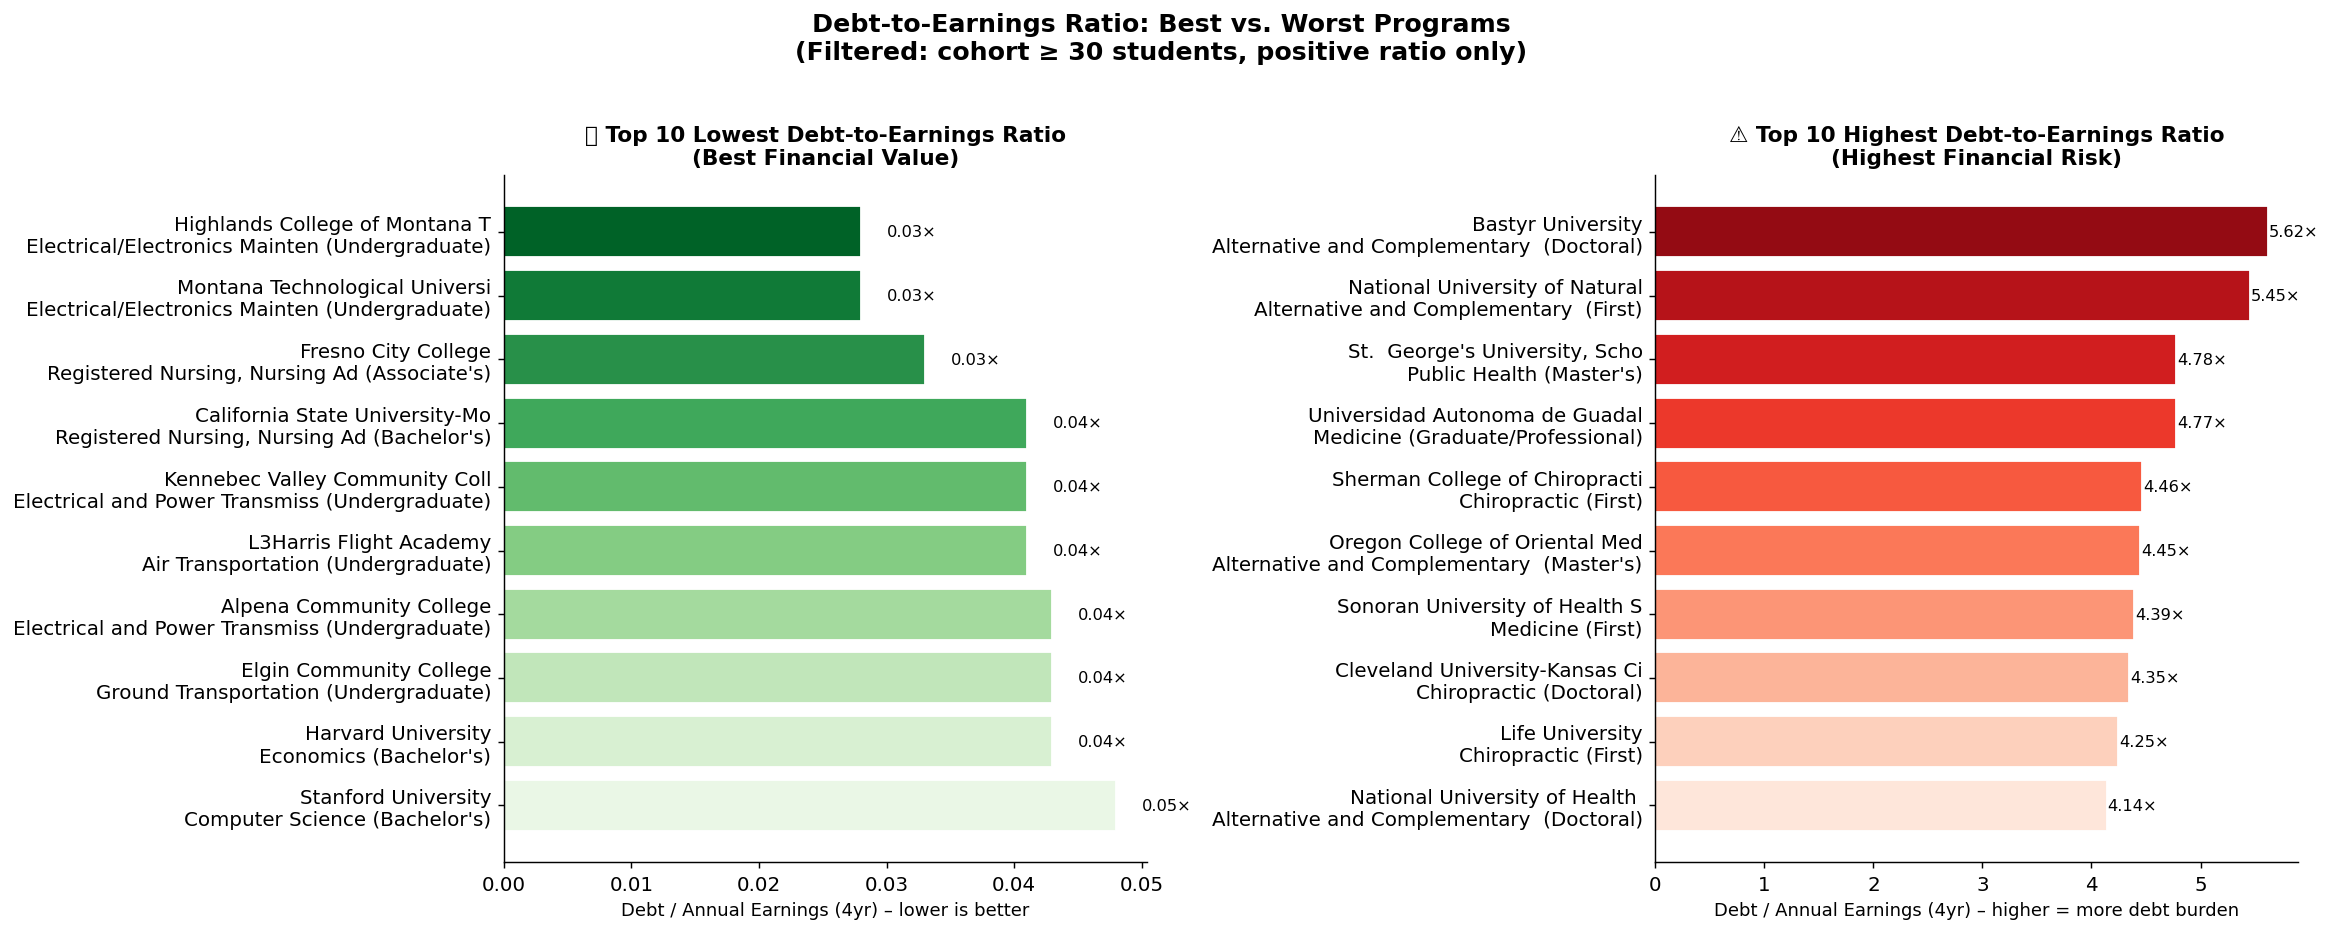

💾 Đã lưu: plot3_debt_to_earnings.png


In [ ]:
# ── 4.1  BIỂU ĐỒ: Thu nhập trung bình theo nhóm ngành ──────────────────────
# Tính median theo cip_family_title (nhóm ngành cấp cao), loại bỏ NaN
earnings_by_field = (
    df.dropna(subset=["median_earnings_4yr_usd", "cip_family_title"])
    .groupby("cip_family_title")["median_earnings_4yr_usd"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("Blues_r", n_colors=len(earnings_by_field))

bars = ax.barh(
    earnings_by_field.index,
    earnings_by_field.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)

# Thêm nhãn giá trị bên phải mỗi thanh
for bar, val in zip(bars, earnings_by_field.values):
    ax.text(
        val + 300, bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center", ha="left", fontsize=9, color="#444"
    )

ax.set_xlabel("Median Earnings 4 Years After Graduation (USD)", fontsize=11)
ax.set_title(
    "Median Earnings by Field of Study (4 Years Post-Graduation)",
    fontsize=13, fontweight="bold", pad=15
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.invert_yaxis()   # Nhóm thu nhập cao nhất ở đầu
plt.tight_layout()
plt.savefig("plot1_earnings_by_field.png", bbox_inches="tight")
plt.show()
print("💾 Đã lưu: plot1_earnings_by_field.png")


# ── 4.2  BIỂU ĐỒ: Tương quan AI Exposure vs Thu nhập ───────────────────────
# Dùng ai_software_occupation_share làm proxy cho "AI Exposure"
# (tỷ lệ nghề nghiệp liên kết với chương trình sử dụng AI software)

# Lọc dữ liệu hợp lệ
scatter_df = df.dropna(subset=["ai_software_occupation_share", "median_earnings_4yr_usd"]).copy()

# Tính correlation coefficient để hiển thị trên biểu đồ
corr = scatter_df["ai_software_occupation_share"].corr(scatter_df["median_earnings_4yr_usd"])

fig, ax = plt.subplots(figsize=(10, 6))

# Tô màu điểm theo nhóm ngành để dễ nhận dạng
# Chọn top-10 nhóm ngành có nhiều dữ liệu nhất để tô màu riêng
top_fields = scatter_df["cip_family_title"].value_counts().head(10).index
scatter_df["field_group"] = scatter_df["cip_family_title"].where(
    scatter_df["cip_family_title"].isin(top_fields), other="Other"
)

sns.scatterplot(
    data=scatter_df,
    x="ai_software_occupation_share",
    y="median_earnings_4yr_usd",
    hue="field_group",
    alpha=0.35,
    s=18,
    linewidth=0,
    ax=ax,
)

# Đường xu hướng tổng thể (regression line)
sns.regplot(
    data=scatter_df,
    x="ai_software_occupation_share",
    y="median_earnings_4yr_usd",
    scatter=False,
    color="red",
    line_kws={"linewidth": 2, "linestyle": "--", "label": f"Trend (r = {corr:.2f})"},
    ax=ax,
)

ax.set_xlabel("AI Software Occupation Share (proportion of linked occupations using AI)", fontsize=11)
ax.set_ylabel("Median Earnings 4yr (USD)", fontsize=11)
ax.set_title(
    "AI Exposure vs. Median Earnings 4 Years Post-Graduation",
    fontsize=13, fontweight="bold", pad=15
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Chú thích correlation
ax.annotate(
    f"Pearson r = {corr:.3f}",
    xy=(0.97, 0.06), xycoords="axes fraction",
    ha="right", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff3cd", edgecolor="#aaa"),
)

ax.legend(title="Field of Study", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("plot2_ai_vs_earnings.png", bbox_inches="tight")
plt.show()
print(f"💾 Đã lưu: plot2_ai_vs_earnings.png")
print(f"📌 Pearson r = {corr:.3f} — {'tương quan thuận' if corr > 0 else 'tương quan nghịch'} giữa AI exposure và thu nhập")


# ── 4.3  BIỂU ĐỒ: Top 10 Debt-to-Earnings cao nhất & thấp nhất ──────────────
# Dùng debt_to_earnings_4yr = median_debt_usd / median_earnings_4yr_usd
# Loại bỏ NaN, giá trị âm, và các chương trình có cohort quá nhỏ (<30 sinh viên)
# để kết quả đáng tin cậy hơn

dte_df = df.dropna(subset=["debt_to_earnings_4yr", "median_earnings_4yr_usd"]).copy()
dte_df = dte_df[
    (dte_df["debt_to_earnings_4yr"] > 0) &
    (dte_df["earnings_cohort_size_4yr"].fillna(0) >= 30)
].copy()

# Tạo nhãn ngắn cho biểu đồ: Tên trường + tên chương trình
dte_df["label"] = (
    dte_df["institution_name"].fillna("Unknown").str[:30]
    + "\n"
    + dte_df["cip_title"].fillna("").str[:30]
    + " ("
    + dte_df["credential_name"].fillna("").str.split().str[0]
    + ")"
)

top10_low  = dte_df.nsmallest(10, "debt_to_earnings_4yr")[["label", "debt_to_earnings_4yr"]]
top10_high = dte_df.nlargest(10, "debt_to_earnings_4yr")[["label", "debt_to_earnings_4yr"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot trái: DTE thấp nhất (hiệu quả tài chính tốt nhất) ---
axes[0].barh(
    top10_low["label"].str.strip(),
    top10_low["debt_to_earnings_4yr"],
    color=sns.color_palette("Greens_r", 10),
    edgecolor="white",
)
for i, val in enumerate(top10_low["debt_to_earnings_4yr"]):
    axes[0].text(val + 0.002, i, f"{val:.2f}×", va="center", fontsize=9)
axes[0].set_title("✅ Top 10 Lowest Debt-to-Earnings Ratio\n(Best Financial Value)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Debt / Annual Earnings (4yr) – lower is better", fontsize=10)
axes[0].invert_yaxis()

# --- Subplot phải: DTE cao nhất (rủi ro tài chính cao nhất) ---
axes[1].barh(
    top10_high["label"].str.strip(),
    top10_high["debt_to_earnings_4yr"],
    color=sns.color_palette("Reds_r", 10),
    edgecolor="white",
)
for i, val in enumerate(top10_high["debt_to_earnings_4yr"]):
    axes[1].text(val + 0.01, i, f"{val:.2f}×", va="center", fontsize=9)
axes[1].set_title("⚠️ Top 10 Highest Debt-to-Earnings Ratio\n(Highest Financial Risk)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Debt / Annual Earnings (4yr) – higher = more debt burden", fontsize=10)
axes[1].invert_yaxis()

plt.suptitle(
    "Debt-to-Earnings Ratio: Best vs. Worst Programs\n"
    "(Filtered: cohort ≥ 30 students, positive ratio only)",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("plot3_debt_to_earnings.png", bbox_inches="tight")
plt.show()
print("💾 Đã lưu: plot3_debt_to_earnings.png")

## **5. XUẤT DỮ LIỆU ĐÃ LÀM SẠCH CHO POWER BI**

In [ ]:
# Chọn các cột quan trọng và hữu ích nhất cho việc phân tích trong Power BI.
# Giữ đủ chiều thông tin: định danh, địa lý, ngành học, thu nhập, nợ, AI, nghề nghiệp.

EXPORT_COLS = [
    # ── Định danh & thông tin trường ────────────────────────────────────────
    "program_id",
    "opeid6",
    "institution_name",
    "institution_control",       # Public / Private nonprofit / Private for-profit
    "is_main_campus",
    "institution_city",
    "institution_state",
    "institution_region",
    "institution_latitude",
    "institution_longitude",
    "institution_is_hbcu",
    "institution_admission_rate",
    "institution_avg_sat",
    "institution_undergrad_enrollment",
    "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd",
    # ── Thông tin chương trình ───────────────────────────────────────────────
    "cip_code_4digit",
    "cip_title",
    "cip_family_code",
    "cip_family_title",          # Nhóm ngành cấp cao (18 nhóm)
    "credential_level",
    "credential_name",           # Certificate / Associate / Bachelor's / Master's / Doctoral
    "distance_education",
    # ── Thu nhập ────────────────────────────────────────────────────────────
    "median_earnings_4yr_usd",
    "earnings_cohort_size_4yr",
    "national_median_earnings_4yr_usd",
    "earnings_vs_national_pct",
    "median_earnings_1yr_usd",
    "median_earnings_5yr_usd",
    "earnings_growth_pct_1yr_to_5yr",
    "earnings_trajectory_category",
    # ── Nợ & tài chính ──────────────────────────────────────────────────────
    "median_debt_usd",
    "median_monthly_payment_usd",
    "debt_to_earnings_1yr",
    "debt_to_earnings_4yr",
    "payment_to_income_pct_1yr",
    # ── Việc làm sau tốt nghiệp ─────────────────────────────────────────────
    "pct_working_5yr",
    "pct_above_hs_threshold_5yr",
    "pct_working_in_state_5yr",
    # ── AI & công nghệ ──────────────────────────────────────────────────────
    "ai_software_occupation_share",
    "expert_system_occupation_share",
    "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation",
    "occupations_using_ai_software",
    "ai_tool_examples",
    # ── Nghề nghiệp liên kết ────────────────────────────────────────────────
    "largest_linked_occupation",
    "occupation_typical_entry_education",
    "occupation_employment_2024_thousands",
    "occupation_growth_pct_2024_34",
    "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd",
    # ── Trạng thái dữ liệu (để lọc trong Power BI) ──────────────────────────
    "earnings_4yr_status",
    "debt_status",
    "outcomes_shared_across_campuses",
]

# Lọc chỉ lấy cột tồn tại trong df
export_cols_available = [c for c in EXPORT_COLS if c in df.columns]
df_export = df[export_cols_available].copy()

OUTPUT_FILE = "cleaned_college_majors.csv"
df_export.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
# encoding="utf-8-sig" thêm BOM để Excel/Power BI nhận diện tiếng Việt đúng

print(f"Đã xuất: {OUTPUT_FILE}")
print(f"Kích thước: {df_export.shape[0]:,} dòng × {df_export.shape[1]} cột")
print(f"\n💡 Hướng dẫn download từ Colab:")
print("   from google.colab import files")
print(f'   files.download("{OUTPUT_FILE}")')
print("\n   Hoặc vào Files panel (biểu tượng folder bên trái) → click chuột phải → Download")

# ── Download ngay (uncomment nếu dùng trên Colab) ───────────────────────────
# from google.colab import files
# files.download(OUTPUT_FILE)

Đã xuất: cleaned_college_majors.csv
Kích thước: 227,980 dòng × 54 cột

💡 Hướng dẫn download từ Colab:
   from google.colab import files
   files.download("cleaned_college_majors.csv")

   Hoặc vào Files panel (biểu tượng folder bên trái) → click chuột phải → Download


## **6. TÓM TẮT NHANH**

In [ ]:
print("\n" + "="*60)
print("📋 TÓM TẮT DATASET SAU LÀM SẠCH")
print("="*60)
print(f"  Tổng số chương trình        : {len(df_export):>10,}")
print(f"  Loại trường (Public/Private): {df_export['institution_control'].value_counts().to_dict()}")
print(f"  Số nhóm ngành (CIP Family)  : {df_export['cip_family_title'].nunique():>10}")
print(f"  Loại bằng (Credential)      : {df_export['credential_name'].nunique():>10}")
print(f"  Tiểu bang có mặt            : {df_export['institution_state'].nunique():>10}")
print(f"  Thu nhập 4yr: ${df_export['median_earnings_4yr_usd'].min():,.0f} – ${df_export['median_earnings_4yr_usd'].max():,.0f}")
print(f"  Nợ trung vị : ${df_export['median_debt_usd'].min():,.0f} – ${df_export['median_debt_usd'].max():,.0f}")
print("="*60)


📋 TÓM TẮT DATASET SAU LÀM SẠCH
  Tổng số chương trình        :    227,980
  Loại trường (Public/Private): {'Public': 137326, 'Private, nonprofit': 72513, 'Private, for-profit': 13479, 'Foreign': 4662}
  Số nhóm ngành (CIP Family)  :         49
  Loại bằng (Credential)      :          9
  Tiểu bang có mặt            :         59
  Thu nhập 4yr: $6,917 – $336,392
  Nợ trung vị : $1,287 – $459,525
